Import Library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

np.random.seed(42)


LOAD DATASET VIA PYTHON

In [3]:
df = pd.read_csv("uiu100k.csv")
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


DATA PREPROCESSING

In [4]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])
df['smoking_history'] = le.fit_transform(df['smoking_history'])


Feature & Target Separation

In [5]:
X = df.drop("diabetes", axis=1).values
y = df["diabetes"].values


Feature Scaling

In [6]:
scaler = StandardScaler()
X = scaler.fit_transform(X)


STRATIFIED TRAIN/VALIDATION/TEST SPLIT

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)


DATA VISUALIZATION

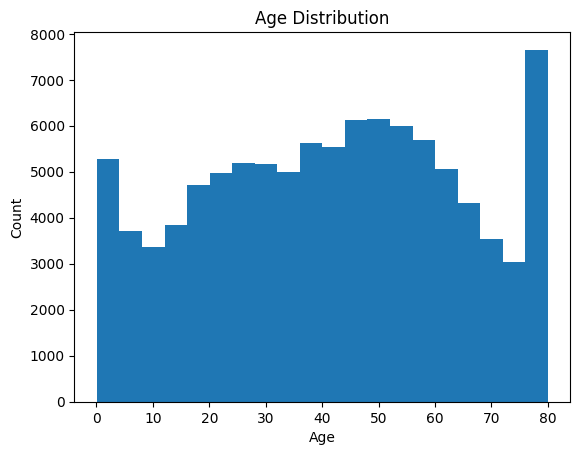

In [8]:
plt.hist(df['age'], bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


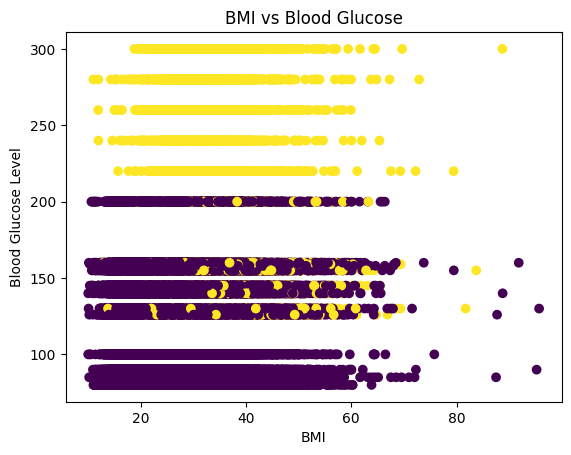

In [9]:
plt.scatter(df['bmi'], df['blood_glucose_level'], c=df['diabetes'])
plt.xlabel("BMI")
plt.ylabel("Blood Glucose Level")
plt.title("BMI vs Blood Glucose")
plt.show()


Hitmap

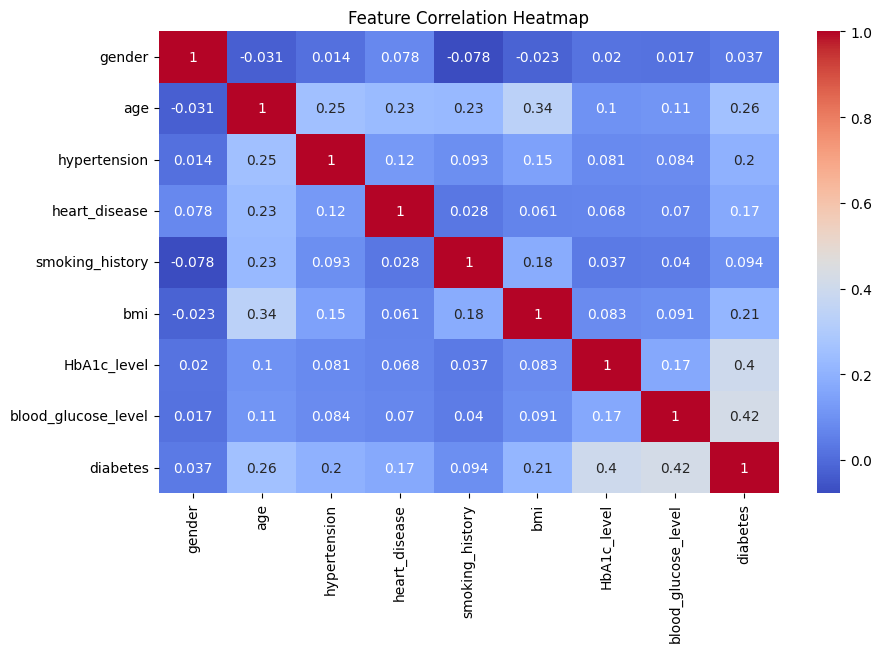

In [10]:
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()


KNN (FROM SCRATCH)

In [11]:
class KNN:
    def __init__(self, k=7):
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        preds = []
        for x in X:
            distances = np.sqrt(np.sum((self.X_train - x)**2, axis=1))
            k_idx = np.argsort(distances)[:self.k]
            k_labels = self.y_train[k_idx]
            preds.append(np.bincount(k_labels).argmax())
        return np.array(preds)


In [12]:
# Create KNN object
knn = KNN(k=7)

# Train KNN
knn.fit(X_train, y_train)

# Predict on test data
y_pred_knn = knn.predict(X_test)


LOGISTIC REGRESSION (FROM SCRATCH)

In [13]:
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=2000, pos_weight=None):
        self.lr = lr
        self.epochs = epochs
        self.pos_weight = pos_weight

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0

        n_pos = np.sum(y == 1)
        n_neg = np.sum(y == 0)
        pos_weight = self.pos_weight if self.pos_weight is not None else (n_neg / n_pos)
        sample_weight = np.where(y == 1, pos_weight, 1.0)

        for _ in range(self.epochs):
            linear = np.dot(X, self.w) + self.b
            y_pred = self.sigmoid(linear)

            error = (y_pred - y) * sample_weight
            dw = np.dot(X.T, error) / len(y)
            db = np.sum(error) / len(y)

            self.w -= self.lr * dw
            self.b -= self.lr * db

    def predict_proba(self, X):
        return self.sigmoid(np.dot(X, self.w) + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)


In [14]:
logreg = LogisticRegressionScratch(lr=0.01, epochs=2000)
logreg.fit(X_train, y_train)

target_recall = 0.85
best_threshold = 0.5
best_f1 = -1
best_recall = -1

for threshold in np.linspace(0.1, 0.9, 161):
    y_val_pred = logreg.predict(X_val, threshold=threshold)
    recall = recall_score(y_val, y_val_pred)
    precision = precision_score(y_val, y_val_pred, zero_division=0)
    f1 = f1_score(y_val, y_val_pred, zero_division=0)

    if recall >= target_recall:
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_recall = recall
    elif best_f1 < 0 and recall > best_recall:
        best_recall = recall
        best_f1 = f1
        best_threshold = threshold

print(f"Selected threshold: {best_threshold:.3f}")
print(f"Validation Recall: {best_recall:.4f}, Validation F1: {best_f1:.4f}")

y_pred_log = logreg.predict(X_test, threshold=best_threshold)


Selected threshold: 0.580
Validation Recall: 0.8515, Validation F1: 0.5958


K-MEANS CLUSTERING (FROM SCRATCH)

In [15]:
class KMeansScratch:
    def __init__(self, k=2, epochs=100):
        self.k = k
        self.epochs = epochs

    def fit(self, X):
        idx = np.random.choice(len(X), self.k, replace=False)
        self.centroids = X[idx]

        for _ in range(self.epochs):
            distances = np.linalg.norm(X[:,None] - self.centroids, axis=2)
            self.labels = np.argmin(distances, axis=1)

            for i in range(self.k):
                self.centroids[i] = X[self.labels == i].mean(axis=0)


In [16]:
kmeans = KMeansScratch()
kmeans.fit(X)


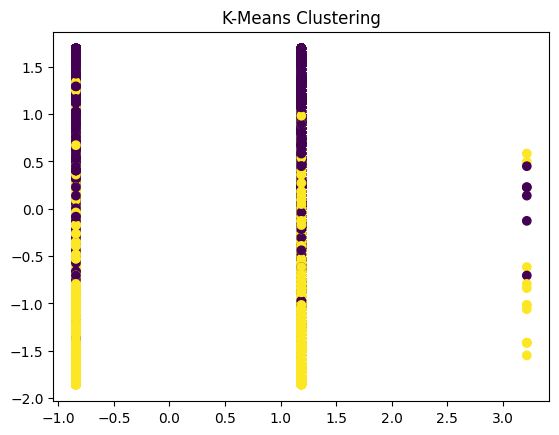

In [17]:
plt.scatter(X[:,0], X[:,1], c=kmeans.labels)
plt.title("K-Means Clustering")
plt.show()


MODEL EVALUATION

In [18]:
def evaluate(y_true, y_pred):
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))


KNN and Logistic Regression data

In [19]:
evaluate(y_test, y_pred_knn)
print(f"Logistic threshold used: {best_threshold:.3f}")
evaluate(y_test, y_pred_log)

Confusion Matrix:
 [[18195   105]
 [  659  1041]]
Accuracy: 0.9618
Precision: 0.9083769633507853
Recall: 0.6123529411764705
F1: 0.7315530569219958
Logistic threshold used: 0.580
Confusion Matrix:
 [[16616  1684]
 [  233  1467]]
Accuracy: 0.90415
Precision: 0.4655664868295779
Recall: 0.8629411764705882
F1: 0.6048237476808905


In [20]:
evaluate(y_test, y_pred_log)

Confusion Matrix:
 [[16616  1684]
 [  233  1467]]
Accuracy: 0.90415
Precision: 0.4655664868295779
Recall: 0.8629411764705882
F1: 0.6048237476808905


ROC CURVE (LOGISTIC REGRESSION)

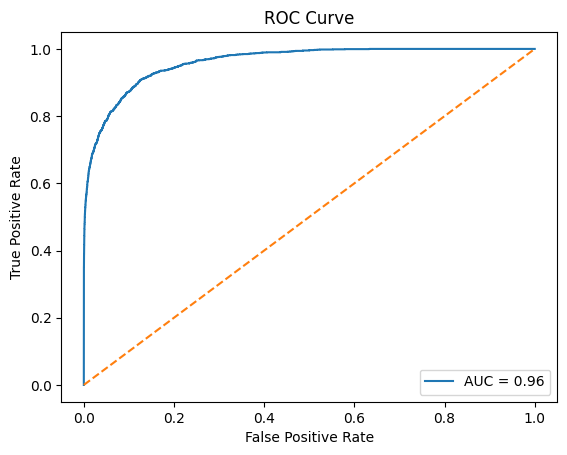

In [21]:
y_test_proba = logreg.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


NEW DATA INPUT & PREDICTION

In [22]:
input_data = np.array([[1, 52.0, 1, 0, 2, 38.0, 6.8, 130]])
input_data = scaler.transform(input_data)

print("KNN:", "Diabetic" if knn.predict(input_data)[0] else "Not Diabetic")
print("Logistic:", "Diabetic" if logreg.predict(input_data, threshold=best_threshold)[0] else "Not Diabetic")


KNN: Diabetic
Logistic: Diabetic
